# 02 Preprocessing: Cleaning, Encoding and the Chronological Split

**IDX Exchange Data Science Internship, Week 3 deliverable**

**Goal.** Turn the raw CRMLS sold files into model-ready data for predicting `ClosePrice` of single-family homes. The Week 3 plan asks for four things: handle missing values, encode categorical fields as numbers, scale numeric fields where needed, and split the data by time, with the most recent month as the test set and the X months before it as training data, where X is chosen by experiment.

**Inputs.** The 28 monthly `CRMLSSold*.csv` files (January 2024 to April 2026) and the findings of `01_exploration.ipynb`.

**Outputs** (written to `data/processed/`, which is kept out of the repository):
- `sfr_clean.csv`: all months after the fixed cleaning rules, with only the model columns
- `train.csv` and `test.csv`: the final split for the chosen training window, after outlier trimming

The split settings and outlier cutoffs are also saved to `config/split_config.json`, which contains no data and is committed.

**Where the code lives.** All cleaning and preprocessing logic is in `src/preprocessing.py`, so that the modeling notebooks of later weeks apply exactly the same steps. This notebook runs those functions, shows their effect, and explains each decision.

**How the steps are ordered.** The best-practices document requires that nothing learned from data may see the test month. The steps therefore fall into three groups:
1. **Fixed rules** that inspect one row at a time (remove duplicates and impossible records). They learn nothing, so they run once on all months.
2. **The split and outlier cutoffs.** The months are divided into training and test, and the 0.5th/99.5th percentile price cutoffs are computed from the training months only.
3. **The fitted preprocessor** (imputation, encoding, scaling), a scikit-learn `ColumnTransformer` that is fit on the training rows and only applied to the test rows.

**Contents**
1. Load the data
2. Fixed cleaning rules
3. Choosing the model columns
4. Training, validation and test months
5. Outlier cutoffs from the training months
6. The preprocessor: missing values, encoding, scaling
7. Choosing the training window X
8. Final split and saved outputs
9. Summary and next steps

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Repo root, whether the notebook runs from notebooks/ or from the root
ROOT = next(p for p in [Path('..'), Path('.')] if (p / 'src' / 'preprocessing.py').exists()).resolve()
sys.path.insert(0, str(ROOT))
import src.preprocessing as prep

# One seed for every random step (target-encoding folds, gradient boosting), so reruns give identical results
SEED = prep.set_global_seed()
print('Random seed:', SEED)

DATA_DIR = ROOT / 'csv'
OUT_DIR = ROOT / 'data' / 'processed'
CONFIG_PATH = ROOT / 'config' / 'split_config.json'
FIG_DIR = ROOT / 'reports' / 'figures'
for d in [OUT_DIR, CONFIG_PATH.parent, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, GRAY, LIGHT_GRAY = '#2a78d6', '#eb6834', '#a3a29d', '#e4e3df'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c9c8c3', 'axes.linewidth': 0.8, 'axes.grid': True,
    'grid.color': LIGHT_GRAY, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e', 'font.size': 9.5,
})
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 120)


def save_fig(name):
    plt.savefig(FIG_DIR / f'{name}.png', dpi=130, bbox_inches='tight')


def money(x, _=None):
    return f'${x / 1e6:.2f}M' if abs(x) >= 1e6 else f'${x / 1e3:.0f}K'

Random seed: 42


## 1. Load the data

`load_sold` stacks the monthly files. As seen in Week 2, the files do not all have the same columns; stacking them with pandas keeps every column and leaves it empty for files that lack it. Each row also gets a `SourceMonth` (the month in its file name), which the deduplication step below uses.

In [2]:
raw = prep.load_sold(DATA_DIR)
source_files = sorted(p.name for p in DATA_DIR.glob('CRMLSSold*.csv'))
print(f'{len(source_files)} files ({source_files[0]} ... {source_files[-1]}), '
      f'{len(raw):,} rows x {raw.shape[1]} columns')

28 files (CRMLSSold202401_filled.csv ... CRMLSSold202604.csv), 615,707 rows x 85 columns


## 2. Fixed cleaning rules

`prep.clean` applies the rules below in this order and logs how many rows each one removes, as the best-practices document asks. Each rule is based on a Week 2 finding:

- **Single-family filter.** The task restricts the model to `PropertyType = Residential` and `PropertySubType = SingleFamilyResidence`.
- **Exact duplicates.** 29 rows were exact copies of another row in the same monthly file.
- **Repeated listings.** `ListingKey` identifies a listing, so it should occur once. Repeated keys turned out to be the same home (same address and living area in all but one case) recorded again in a later monthly file, usually with an updated close date. We keep the most recent record. Doing this before the split matters: otherwise one sale could appear in both the training and the test months.
- **Missing or non-positive price.** The target must be a real sale price.
- **Out-of-state records.** The model is for California.
- **Impossible dates.** A sale cannot close before its listing started or before the purchase contract was signed.
- **Implausible living area.** Living area is the most important size measure and is needed for the price-per-square-foot check in Section 5. Homes with no living area, under 300 sq ft or over 20,000 sq ft are removed.
- **Implausible room counts.** More than 15 bedrooms or bathrooms in a single-family home is almost always a typing error.

In [3]:
clean_df, row_log, value_log = prep.clean(raw)
n_sfr = row_log.loc[1, 'rows_after']
row_log['pct_of_sfr_removed'] = np.where(row_log.index >= 2, (100 * row_log['rows_removed'] / n_sfr).round(3), np.nan)
print(f'Single-family rows: {n_sfr:,}  ->  after cleaning: {len(clean_df):,}  '
      f'({n_sfr - len(clean_df):,} removed, {100 * (n_sfr - len(clean_df)) / n_sfr:.2f}%)')
row_log

Single-family rows: 309,735  ->  after cleaning: 308,862  (873 removed, 0.28%)


,step,rows_before,rows_removed,rows_after,pct_removed,pct_of_sfr_removed
0,Keep PropertyType = Residential,615707,201653,414054,32.751,NaN
1,Keep PropertySubType = SingleFamilyResidence,414054,104319,309735,25.195,NaN
2,Drop exact duplicate rows,309735,29,309706,0.009,0.009
3,Keep latest record per ListingKey,309706,235,309471,0.076,0.076
4,Drop ClosePrice missing or <= 0,309471,2,309469,0.001,0.001
5,Drop StateOrProvince other than CA,309469,22,309447,0.007,0.007
6,Drop CloseDate before ListingContractDate,309447,44,309403,0.014,0.014
7,Drop CloseDate before PurchaseContractDate,309403,194,309209,0.063,0.063
8,"Drop LivingArea missing, < 300 or > 20,000 sqft",309209,328,308881,0.106,0.106
9,Drop more than 15 bedrooms or bathrooms,308881,19,308862,0.006,0.006


Some problems affect one value in an otherwise usable row. Removing the whole row would waste the other columns, so these values are set to missing and filled in later by the fitted preprocessor (Section 6). Two columns can also be partly filled from a second column that records the same fact: lot size from `LotSizeAcres` (1 acre = 43,560 sq ft), and the number of stories from the `Levels` text field ("One", "Two", "ThreeOrMore").

In [4]:
value_log

,fix,column,values_set_missing,values_filled
0,0 bedrooms,BedroomsTotal,121,0
1,0 bathrooms,BathroomsTotalInteger,78,0
2,YearBuilt before 1850 or after year of sale,YearBuilt,8,0
3,Coordinates outside California,Latitude,62,0
4,Lot size of 0 sqft,LotSizeSquareFeet,162,0
5,"Lot size filled from LotSizeAcres x 43,560",LotSizeSquareFeet,0,20
6,Stories filled from Levels,Stories,0,5819


## 3. Choosing the model columns

The model uses 17 inputs, listed below. Fifteen are columns of the files used as they are; two are derived from other columns: `ZIP5` (the first five digits of `PostalCode`) and `AssociationFeeMonthly`. Every excluded column falls into one of the groups in the second table. The leakage group is the most important: these columns are set during the sale process, so they are unknown for a home that is not for sale. `sfr_clean.csv` contains only the identifiers, the date, the inputs and the target, so later notebooks cannot use a leaking column by accident.

For the monthly fee: `AssociationFee` is reported per month, quarter, half-year or year, so it is divided by the number of months in its period; a positive fee with no stated period (712 rows) is assumed to be monthly. Engineered features such as the age of the home and the school-district layer are left for Week 6, so that their effect can be measured against this feature set.

In [5]:
meaning = {
    'LivingArea': 'interior living area (sq ft)',
    'LotSizeSquareFeet': 'land area (sq ft)',
    'BedroomsTotal': 'number of bedrooms',
    'BathroomsTotalInteger': 'number of bathrooms',
    'YearBuilt': 'year of construction',
    'GarageSpaces': 'garage spaces',
    'Stories': 'number of stories',
    'AssociationFeeMonthly': 'homeowners-association fee per month ($)',
    'Latitude': 'latitude', 'Longitude': 'longitude',
    'PoolPrivateYN': 'has a private pool', 'ViewYN': 'has a view',
    'AttachedGarageYN': 'garage attached to the house', 'FireplaceYN': 'has a fireplace',
    'NewConstructionYN': 'newly built',
    'CountyOrParish': 'county', 'ZIP5': '5-digit ZIP code',
}
treatment = {}
for c in prep.LOG_FEATURES:
    treatment[c] = 'clip to p0.5/p99.5, log, median impute + missing flag, scale'
for c in prep.NUMERIC_FEATURES:
    treatment[c] = 'clip to p0.5/p99.5, median impute + missing flag, scale'
for c in prep.COORD_FEATURES:
    treatment[c] = 'fill from ZIP / county median, flag filled rows, scale'
for c in prep.BOOL_FEATURES:
    treatment[c] = 'yes = 1, no = 0; missing = 0 + missing flag'
treatment['CountyOrParish'] = 'one-hot (counties with < 50 training sales grouped)'
treatment['ZIP5'] = 'target encoding (cross-fitted), scale'

features_table = pd.DataFrame({
    'meaning': pd.Series(meaning),
    'missing_pct': (100 * clean_df[prep.FEATURES].isna().mean()).round(2),
    'treatment': pd.Series(treatment),
}).loc[prep.FEATURES]
features_table

,meaning,missing_pct,treatment
LivingArea,interior living area (sq ft),0.00,"clip to p0.5/p99.5, log, median impute + missing flag, scale"
LotSizeSquareFeet,land area (sq ft),1.77,"clip to p0.5/p99.5, log, median impute + missing flag, scale"
BedroomsTotal,number of bedrooms,0.04,"clip to p0.5/p99.5, median impute + missing flag, scale"
BathroomsTotalInteger,number of bathrooms,0.04,"clip to p0.5/p99.5, median impute + missing flag, scale"
YearBuilt,year of construction,0.06,"clip to p0.5/p99.5, median impute + missing flag, scale"
GarageSpaces,garage spaces,3.66,"clip to p0.5/p99.5, median impute + missing flag, scale"
Stories,number of stories,10.77,"clip to p0.5/p99.5, median impute + missing flag, scale"
AssociationFeeMonthly,homeowners-association fee per month ($),30.13,"clip to p0.5/p99.5, median impute + missing flag, scale"
Latitude,latitude,0.89,"fill from ZIP / county median, flag filled rows, scale"
Longitude,longitude,0.89,"fill from ZIP / county median, flag filled rows, scale"


In [6]:
used = set(prep.FEATURES) | {prep.TARGET, 'ListingKey', 'CloseDate'}
sfr_raw = raw[(raw['PropertyType'] == 'Residential') & (raw['PropertySubType'] == 'SingleFamilyResidence')]
miss = sfr_raw.isna().mean()

groups = {
    'Leakage: set during the sale process': prep.LEAKAGE_COLUMNS,
    'Empty for single-family homes': [c for c in raw.columns if miss[c] == 1],
    'More than 50% missing': [c for c in raw.columns if 0.5 < miss[c] < 1 and c not in prep.LEAKAGE_COLUMNS],
    'Agent and office': [c for c in raw.columns if 'Agent' in c or 'Office' in c],
    'Identifiers and system fields': ['ListingKeyNumeric', 'ListingId', 'MlsStatus', 'PropertyType',
                                      'PropertySubType', 'SourceMonth', 'StateOrProvince'],
    'Process dates (used for cleaning only)': ['ListingContractDate', 'PurchaseContractDate',
                                               'ContractStatusChangeDate'],
    'Same fact as a kept column': ['LotSizeAcres', 'LotSizeArea', 'Levels', 'AssociationFee',
                                   'AssociationFeeFrequency', 'PostalCode', 'City', 'MLSAreaMajor',
                                   'UnparsedAddress', 'StreetNumberNumeric', 'ParkingTotal'],
    'Deferred to later weeks': ['Flooring', 'MainLevelBedrooms', 'HighSchoolDistrict'],
}
# Each excluded column is listed under the first group it matches
exclusive, seen = {}, set(used)
for g, cs in groups.items():
    exclusive[g] = [c for c in cs if c in raw.columns and c not in seen]
    seen |= set(exclusive[g])
leftover = [c for c in raw.columns if c not in seen]
assert not leftover, leftover

pd.DataFrame({'columns': {g: len(cs) for g, cs in exclusive.items()},
              'names': {g: ', '.join(cs) for g, cs in exclusive.items()}})

,columns,names
Leakage: set during the sale process,5,"ListPrice, OriginalListPrice, DaysOnMarket, BuyerAgencyCompensation, BuyerAgencyCompensationType"
Empty for single-family homes,8,"FireplacesTotal, AboveGradeFinishedArea, TaxAnnualAmount, TaxYear, ElementarySchoolDistrict, BusinessType, CoveredSp..."
More than 50% missing,19,"WaterfrontYN, BasementYN, CoListOfficeName, CoListAgentFirstName, CoListAgentLastName, AssociationFeeFrequency, Elem..."
Agent and office,12,"ListAgentEmail, ListAgentFirstName, ListAgentLastName, ListOfficeName, BuyerOfficeName, ListAgentFullName, BuyerAgen..."
Identifiers and system fields,7,"ListingKeyNumeric, ListingId, MlsStatus, PropertyType, PropertySubType, SourceMonth, StateOrProvince"
Process dates (used for cleaning only),3,"ListingContractDate, PurchaseContractDate, ContractStatusChangeDate"
Same fact as a kept column,10,"LotSizeAcres, LotSizeArea, Levels, AssociationFee, PostalCode, City, MLSAreaMajor, UnparsedAddress, StreetNumberNume..."
Deferred to later weeks,3,"Flooring, MainLevelBedrooms, HighSchoolDistrict"


`ParkingTotal` is excluded because it overlaps with `GarageSpaces` and contains impossible values (from -143 to 15,720). `Flooring` is a multi-valued text field, `MainLevelBedrooms` is 40% missing and largely repeats the bedroom count, and `HighSchoolDistrict` will be replaced by the Week 6 school-district join.

## 4. Training, validation and test months

The best-practices document prescribes a chronological split, never a random one, because a production model is always trained on the past and used on the future:

- **Test month:** the most recent month, April 2026. It is used once, at the very end of the project, to report final results.
- **Validation month:** the month before, March 2026. Model settings, including the training window X, are chosen by their error on this month, so that no setting is chosen by looking at the test month.
- **Training months:** the X months immediately before the month being predicted.

The same pattern is used twice. To choose settings, the model is trained on the X months before March 2026 and scored on March 2026. For the final result, it is trained on the X months before April 2026 (now including March) and scored on April 2026. Because a single validation month can be lucky or unlucky, Section 7 also scores January and February 2026, each with its own X-month window before it, and averages the three.

In [7]:
months = sorted(clean_df['CloseMonth'].unique())
TEST_MONTH = months[-1]
VALIDATION_MONTH = months[-2]
VALIDATION_MONTHS = months[-4:-1]   # Jan, Feb, Mar 2026: each scored with its own window
print('Test month:', TEST_MONTH, '| validation month:', VALIDATION_MONTH,
      '| months used to choose X:', VALIDATION_MONTHS)

per_month = clean_df.groupby('CloseMonth').size()
print(f'Sales per month after cleaning: min {per_month.min():,} ({per_month.idxmin()}), '
      f'max {per_month.max():,} ({per_month.idxmax()})')

Test month: 2026-04 | validation month: 2026-03 | months used to choose X: ['2026-01', '2026-02', '2026-03']
Sales per month after cleaning: min 7,467 (2026-01), max 13,777 (2024-05)


## 5. Outlier cutoffs from the training months

`make_split` selects the months, then computes four cutoffs from the training rows only: the 0.5th and 99.5th percentiles of sale price, and the same percentiles of price per square foot. The second pair catches errors the price alone hides, such as an ordinary price for a home whose living area was mistyped. Both training and evaluation rows outside the cutoffs are removed, using the identical numbers for both.

Shown here for the final split with a 12-month window (the choice of 12 is explained in Section 7):

In [8]:
tr_example, te_example, bounds_example = prep.make_split(clean_df, TEST_MONTH, 12)
n_tr_before = clean_df['CloseMonth'].isin(months[-13:-1]).sum()
n_te_before = (clean_df['CloseMonth'] == TEST_MONTH).sum()
print('Cutoffs (from the 12 training months only):')
print(f"  price:          {money(bounds_example['price_low'])} to {money(bounds_example['price_high'])}")
print(f"  price per sqft: ${bounds_example['ppsf_low']:,.0f} to ${bounds_example['ppsf_high']:,.0f}")
print(f'Training rows: {n_tr_before:,} -> {len(tr_example):,} ({100 * (1 - len(tr_example) / n_tr_before):.2f}% removed)')
print(f'Test rows:     {n_te_before:,} -> {len(te_example):,} ({100 * (1 - len(te_example) / n_te_before):.2f}% removed)')

Cutoffs (from the 12 training months only):
  price:          $185K to $8.60M
  price per sqft: $144 to $2,299
Training rows: 130,281 -> 128,330 (1.50% removed)
Test rows:     12,475 -> 12,268 (1.66% removed)


## 6. The preprocessor: missing values, encoding, scaling

`prep.build_preprocessor()` returns one scikit-learn `ColumnTransformer` that turns the 17 input columns into a numeric matrix. Everything it learns is learned in `fit`, which only ever receives training rows; the test rows only pass through `transform`. Each group of columns has its own sequence of steps:

| Columns | Steps (in order) | Why |
|---|---|---|
| Living area, lot size | clip to the training 0.5th/99.5th percentiles, take `log(1 + x)`, fill missing with the training median and add a 0/1 missing flag, standardize | both are right-skewed; clipping limits typing errors such as the 2.1 billion sq ft lot |
| Bedrooms, bathrooms, year built, garage spaces, stories, monthly fee | clip, fill median + missing flag, standardize | same, without the log |
| Latitude, longitude | fill missing with the training median of the home's ZIP code, else of its county, else overall; add a flag for filled rows; standardize | a ZIP-level guess is far closer than a statewide median |
| Pool, view, attached garage, fireplace, new construction | yes = 1, no = 0, missing = 0 plus a missing flag | missingness itself may relate to price |
| County | one-hot encoding; counties with fewer than 50 training sales share one column | about 60 values, few enough for one-hot |
| ZIP code | target encoding, then standardize | about 3,000 values, too many for one-hot |

**Target encoding** replaces each ZIP code by the average log sale price of training homes in that ZIP code, shrunk toward the overall average when the ZIP code has few sales. To keep a home's own price out of its encoding, the training rows are split into 5 parts and each part is encoded using averages from the other 4 (scikit-learn's `TargetEncoder` does this inside `fit`). ZIP codes that never occur in training get the overall average.

**Standardizing** (subtracting the training mean and dividing by the training standard deviation) matters for regularized linear models and distance-based methods. Tree models are unaffected by it, so one preprocessor serves both.

The cell below fits the preprocessor on the 12-month training rows of the final split and checks the result.

In [9]:
pre = prep.build_preprocessor()
X_train = pre.fit_transform(tr_example[prep.FEATURES], np.log(tr_example[prep.TARGET]))
X_test = pre.transform(te_example[prep.FEATURES])
names = pre.get_feature_names_out()

blocks = pd.Series([n.split('__')[0] for n in names]).value_counts().reindex(
    ['log_numeric', 'numeric', 'coords', 'booleans', 'county', 'zip'])
print(f'Matrix: {X_train.shape[0]:,} training rows x {X_train.shape[1]} columns '
      f'(test: {X_test.shape[0]:,} rows); no missing values left: {not np.isnan(X_train).any()}')
print('Columns per block:', blocks.to_dict())

scaled = [i for i, n in enumerate(names) if n.split('__')[0] in ('log_numeric', 'numeric', 'coords', 'zip')
          and 'missingindicator' not in n and 'coords_imputed' not in n]
print(f'Standardized columns on training rows: mean within {np.abs(X_train[:, scaled].mean(0)).max():.1e} of 0, '
      f'std {X_train[:, scaled].std(0).min():.3f} to {X_train[:, scaled].std(0).max():.3f}')
print(f'Same columns on test rows (transformed with training statistics): '
      f'means from {X_test[:, scaled].mean(0).min():.2f} to {X_test[:, scaled].mean(0).max():.2f}')

unseen_zip = ~te_example[prep.ZIP_FEATURE].isin(tr_example[prep.ZIP_FEATURE].unique())
print(f'Test homes in ZIP codes absent from training: {unseen_zip.sum()} ({100 * unseen_zip.mean():.2f}%)')

Matrix: 128,330 training rows x 65 columns (test: 12,268 rows); no missing values left: True
Columns per block: {'log_numeric': 3, 'numeric': 12, 'coords': 3, 'booleans': 10, 'county': 36, 'zip': 1}
Standardized columns on training rows: mean within 5.3e-15 of 0, std 1.000 to 1.000
Same columns on test rows (transformed with training statistics): means from -0.01 to 0.05
Test homes in ZIP codes absent from training: 19 (0.15%)


Three structural checks on leakage, matching the best-practices self-check list:

In [10]:
assert not set(prep.LEAKAGE_COLUMNS) & set(clean_df.columns), 'a leakage column reached the clean data'
assert tr_example['CloseMonth'].max() < TEST_MONTH, 'training rows from the test month or later'
assert bounds_example == prep.fit_outlier_bounds(clean_df[clean_df['CloseMonth'].isin(months[-13:-1])]), \
    'outlier cutoffs are not the training-month cutoffs'
print('Leakage columns excluded; training months precede the test month; cutoffs come from training months.')

Leakage columns excluded; training months precede the test month; cutoffs come from training months.


## 7. Choosing the training window X

A longer window gives the model more examples, which helps most for rare cases such as small ZIP codes and very large homes. A shorter window keeps the training data closer to current market conditions, since prices drift and the model has no input describing time. Which effect wins is an empirical question, so we measure it.

**The experiment.** For each window length X in {1, 2, 3, 4, 6, 9, 12, 18, 24} months and each validation month in {January, February, March 2026}, train on the X months before the validation month (with outlier cutoffs from those X months) and record the validation error. The test month, April 2026, is not used.

**The models.** Two quick models, used only to compare windows; proper modeling starts in Week 4.
- Linear regression on the preprocessed inputs, predicting log price (a preview of the Week 4 baseline).
- Gradient-boosted trees (scikit-learn's `HistGradientBoostingRegressor`, 300 trees, default settings), predicting log price. Tree models capture nonlinear effects such as location clusters, so their best window could differ from the linear model's.

**The measure.** MdAPE, the median over homes of |predicted price − sale price| / sale price, which the best-practices document names as the headline error measure. R², MAPE (the mean of the same ratio) and MAE (mean absolute error in dollars) are also recorded.

In [11]:
WINDOWS = [1, 2, 3, 4, 6, 9, 12, 18, 24]
MODELS = {
    'Linear regression': lambda: LinearRegression(),
    'Gradient boosting': lambda: HistGradientBoostingRegressor(max_iter=300, random_state=prep.RANDOM_STATE),
}


def fit_model(train, make_model):
    model = TransformedTargetRegressor(
        regressor=Pipeline([('pre', prep.build_preprocessor()), ('model', make_model())]),
        func=np.log, inverse_func=np.exp)
    return model.fit(train[prep.FEATURES], train[prep.TARGET])


results = []
for val_month in VALIDATION_MONTHS:
    for n_months in WINDOWS:
        train, val, _ = prep.make_split(clean_df, val_month, n_months)
        for model_name, make_model in MODELS.items():
            model = fit_model(train, make_model)
            results.append({'validation_month': val_month, 'X': n_months, 'model': model_name,
                            'train_rows': len(train), 'validation_rows': len(val),
                            **prep.regression_metrics(val[prep.TARGET], model.predict(val[prep.FEATURES]))})
results = pd.DataFrame(results)

summary = (results.groupby(['model', 'X'])
           .agg(train_rows=('train_rows', 'mean'), MdAPE=('MdAPE', 'mean'), MdAPE_month_sd=('MdAPE', 'std'),
                MAPE=('MAPE', 'mean'), R2=('R2', 'mean'), MAE=('MAE', 'mean'))
           .round({'train_rows': 0, 'MdAPE': 2, 'MdAPE_month_sd': 2, 'MAPE': 2, 'R2': 3, 'MAE': 0}))
summary

train_rows  MdAPE  MdAPE_month_sd   MAPE     R2       MAE
model             X                                                            
Gradient boosting 1       8818.0   9.75            0.27  13.87  0.846  181966.0
                  2      17884.0   9.04            0.23  12.95  0.868  170341.0
                  3      28440.0   8.70            0.18  12.50  0.879  164156.0
                  4      39323.0   8.55            0.12  12.25  0.883  160797.0
                  6      62235.0   8.46            0.17  12.06  0.887  158605.0
                  9      96972.0   8.38            0.07  11.92  0.891  155599.0
                  12    127475.0   8.28            0.08  11.82  0.894  153938.0
                  18    191952.0   8.24            0.09  11.76  0.895  152659.0
                  24    263516.0   8.29            0.03  11.79  0.895  152646.0
Linear regression 1       8818.0  12.72            0.24  16.87  0.787  216583.0
                  2      17884.0  12.27            0.13  16.20  0.795  211132.0
                  3      28440.0  11.97            0.12  15.86  0.801  207682.0
                  4      39323.0  11.83            0.09  15.67  0.802  206058.0
                  6      62235.0  11.70            0.07  15.48  0.804  204338.0
                  9      96972.0  11.52            0.04  15.40  0.809  202574.0
                  12    127475.0  11.51            0.10  15.42  0.812  201639.0
                  18    191952.0  11.46            0.07  15.34  0.813  200641.0
                  24    263516.0  11.43            0.15  15.33  0.813  200234.0

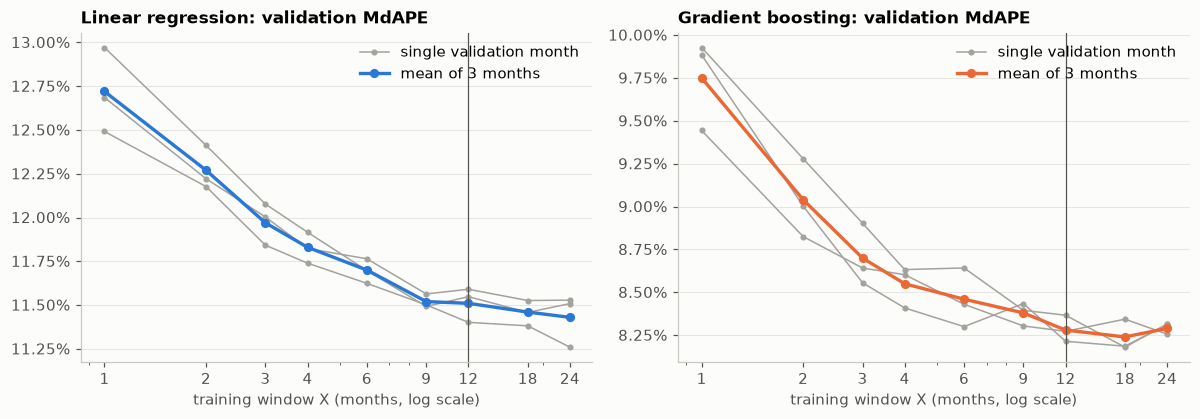

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
for ax, (model_name, color) in zip(axes, [('Linear regression', BLUE), ('Gradient boosting', ORANGE)]):
    r = results[results['model'] == model_name]
    for k, m in enumerate(VALIDATION_MONTHS):
        rm = r[r['validation_month'] == m]
        ax.plot(rm['X'], rm['MdAPE'], color=GRAY, lw=1, marker='o', ms=3,
                label='single validation month' if k == 0 else None)
    mean = summary.loc[model_name, 'MdAPE']
    ax.plot(mean.index, mean.values, color=color, lw=2.2, marker='o', ms=5, label='mean of 3 months')
    ax.axvline(12, color='#52514e', lw=0.8)
    ax.set_xscale('log')
    ax.set_xticks(WINDOWS, [str(w) for w in WINDOWS])
    ax.xaxis.set_minor_formatter(mtick.NullFormatter())
    ax.set_xlim(0.85, 28)
    ax.set_xlabel('training window X (months, log scale)')
    ax.set_title(f'{model_name}: validation MdAPE')
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.2f}%'))
    ax.legend(frameon=False, loc='upper right')
    ax.grid(axis='x', visible=False)
plt.tight_layout()
save_fig('02_training_window')
plt.show()

**Reading the result.** For both models the error falls steeply up to about 6 to 9 months and is nearly flat from 12 months on. Between 12 and 24 months, the mean MdAPE changes by less than 0.1 percentage points. That is comparable to the standard deviation across the three validation months at a fixed window (the `MdAPE_month_sd` column, about 0.1), so differences of that size cannot be told apart from month-to-month variation.

**Choice: X = 12 months.** We take the shortest window whose mean MdAPE is within 0.1 percentage points of the best window for both models at once. The code below applies this rule. Beyond the numbers, 12 months has a natural interpretation: the training data contains each calendar month exactly once, so every season is represented equally, and it is the most recent full year of market conditions. X remains a setting that later weeks may tune again for their own models.

In [13]:
TOLERANCE = 0.1  # percentage points of MdAPE
mean_mdape = results.groupby(['model', 'X'])['MdAPE'].mean().unstack('model')   # unrounded
gap_to_best = mean_mdape - mean_mdape.min()
ok_for_both = gap_to_best[(gap_to_best <= TOLERANCE).all(axis=1)]
N_TRAIN_MONTHS = int(ok_for_both.index.min())
print('Gap to the best window, in MdAPE percentage points:')
print(gap_to_best.round(3).to_string())
print('Chosen X =', N_TRAIN_MONTHS)

Gap to the best window, in MdAPE percentage points:
model  Gradient boosting  Linear regression
X                                          
1                  1.515              1.284
2                  0.799              0.838
3                  0.464              0.542
4                  0.312              0.394
6                  0.221              0.263
9                  0.141              0.087
12                 0.048              0.081
18                 0.000              0.023
24                 0.058              0.000
Chosen X = 12


## 8. Final split and saved outputs

With X = 12 the final split is: train on April 2025 through March 2026, test on April 2026. For choosing model settings in Weeks 4 to 7, the same window shifted back one month applies: train on March 2025 through February 2026 and validate on March 2026. Both are recorded in the configuration file.

In [14]:
train_final, test_final, bounds_final = prep.make_split(clean_df, TEST_MONTH, N_TRAIN_MONTHS)
train_tune, val_tune, bounds_tune = prep.make_split(clean_df, VALIDATION_MONTH, N_TRAIN_MONTHS)


def window(df):
    return f"{df['CloseMonth'].min()} to {df['CloseMonth'].max()}"


split_summary = pd.DataFrame({
    'months': [window(train_tune), VALIDATION_MONTH, window(train_final), TEST_MONTH],
    'rows': [len(train_tune), len(val_tune), len(train_final), len(test_final)],
    'median_price': [d[prep.TARGET].median() for d in [train_tune, val_tune, train_final, test_final]],
}, index=['tuning: train', 'tuning: validation', 'final: train', 'final: test'])
split_summary

,months,rows,median_price
tuning: train,2025-03 to 2026-02,127358,885000.0
tuning: validation,2026-03,11354,890000.0
final: train,2025-04 to 2026-03,128330,885000.0
final: test,2026-04,12268,910500.0


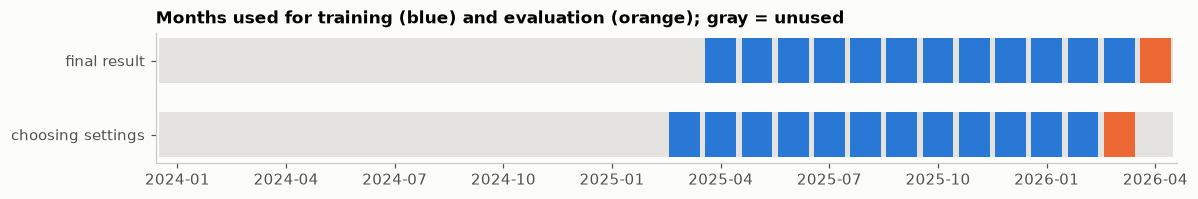

In [15]:
fig, ax = plt.subplots(figsize=(11, 1.9))
roles = [('final: train', train_final['CloseMonth'].unique(), 1, BLUE),
         ('final: test', [TEST_MONTH], 1, ORANGE),
         ('tuning: train', train_tune['CloseMonth'].unique(), 0, BLUE),
         ('tuning: validation', [VALIDATION_MONTH], 0, ORANGE)]
idx = {m: i for i, m in enumerate(months)}
for label, ms, row, color in roles:
    for m in ms:
        ax.barh(row, 0.85, left=idx[m] - 0.425, height=0.6, color=color)
ax.barh([0, 1], [len(months)] * 2, left=-0.5, height=0.6, color=LIGHT_GRAY, zorder=0)
ax.set_yticks([0, 1], ['choosing settings', 'final result'])
ax.set_xticks(range(0, len(months), 3), [months[i] for i in range(0, len(months), 3)])
ax.set_xlim(-0.6, len(months) - 0.4)
ax.grid(False)
ax.set_title('Months used for training (blue) and evaluation (orange); gray = unused')
plt.tight_layout()
save_fig('02_split_timeline')
plt.show()

In [16]:
clean_df.to_csv(OUT_DIR / 'sfr_clean.csv', index=False)
train_final.to_csv(OUT_DIR / 'train.csv', index=False)
test_final.to_csv(OUT_DIR / 'test.csv', index=False)

config = {
    'data_snapshot': {'files': len(source_files), 'first_file': source_files[0], 'last_file': source_files[-1],
                      'raw_rows': int(len(raw)), 'clean_rows': int(len(clean_df))},
    'random_seed': SEED,
    'n_train_months': N_TRAIN_MONTHS,
    'final': {'train_months': sorted(train_final['CloseMonth'].unique().tolist()), 'test_month': TEST_MONTH,
              'outlier_bounds': bounds_final, 'train_rows': int(len(train_final)), 'test_rows': int(len(test_final))},
    'tuning': {'train_months': sorted(train_tune['CloseMonth'].unique().tolist()),
               'validation_month': VALIDATION_MONTH, 'outlier_bounds': bounds_tune},
    'window_selection': {'validation_months': VALIDATION_MONTHS, 'windows_tried': WINDOWS,
                         'rule': f'shortest window within {TOLERANCE} MdAPE points of the best, for both models',
                         'mean_validation_mdape': {m: {str(x): round(float(v), 3) for x, v in mean_mdape[m].items()}
                                                   for m in MODELS}},
    'features': prep.FEATURES,
    'target': prep.TARGET,
    'excluded_leakage_columns': prep.LEAKAGE_COLUMNS,
}
CONFIG_PATH.write_text(json.dumps(config, indent=2))

for f in ['sfr_clean.csv', 'train.csv', 'test.csv']:
    print(f'{f:15s} {(OUT_DIR / f).stat().st_size / 1e6:6.1f} MB')
print('config written to', CONFIG_PATH.relative_to(ROOT))

sfr_clean.csv     45.4 MB
train.csv         18.9 MB
test.csv           1.8 MB
config written to config\split_config.json


## 9. Summary and next steps

**What the cleaning did**
- The fixed rules removed 873 of the 309,735 single-family rows (0.28%), leaving 308,862. The largest removals were implausible living areas (328 rows), older copies of repeated listings (235) and sales closing before the purchase contract date (194).
- 431 individual values were set to missing instead of removing their rows (for example 162 lots of 0 sq ft and 121 homes with 0 bedrooms), and 5,839 missing values were filled from a second column holding the same fact (mostly stories from `Levels`).

**What goes into the model**
- 17 inputs: 15 columns used as they are plus the 5-digit ZIP code and the monthly association fee. Leakage columns, agent and office fields, identifiers and mostly empty columns are excluded, and `sfr_clean.csv` does not contain them.
- The fitted preprocessor turns the 17 inputs into 65 numeric columns for the final training set: scaled numbers, 0/1 missing flags, 36 county columns and one target-encoded ZIP column. It is fit on training rows only.

**The split**
- X = 12 training months. For both quick models, validation error falls steeply up to about 9 months and changes by less than 0.1 percentage points of MdAPE between 12 and 24 months, a difference comparable to the variation between validation months. Twelve months is the shortest window within that margin for both models, and it contains each calendar month once.
- Final split: 128,330 training sales (April 2025 to March 2026) and 12,268 test sales (April 2026), after removing sales outside the training-month cutoffs of $185K to $8.60M and $144 to $2,299 per sq ft.
- Settings split for Weeks 4 to 7: train on March 2025 to February 2026 (127,358 sales), validate on March 2026 (11,354 sales).
- With X = 12, the quick models reached a mean validation MdAPE of 11.5% (linear regression) and 8.3% (gradient boosting). These are validation numbers; the test month has not been used.

**Next steps (Week 4, `03_baseline_model.ipynb`)**
1. Load `train.csv`/`test.csv`, or rebuild them with `prep.make_split`, and the settings in `config/split_config.json`.
2. Fit the linear regression baseline with this preprocessor on the settings split and report R², MAPE, MdAPE and MAE on March 2026.
3. Fit it once on the final split and report the same measures on April 2026 as the recorded baseline.
4. Repeat the evaluation at two earlier cutoff months, as the best-practices document asks, to check that the baseline is stable over time.